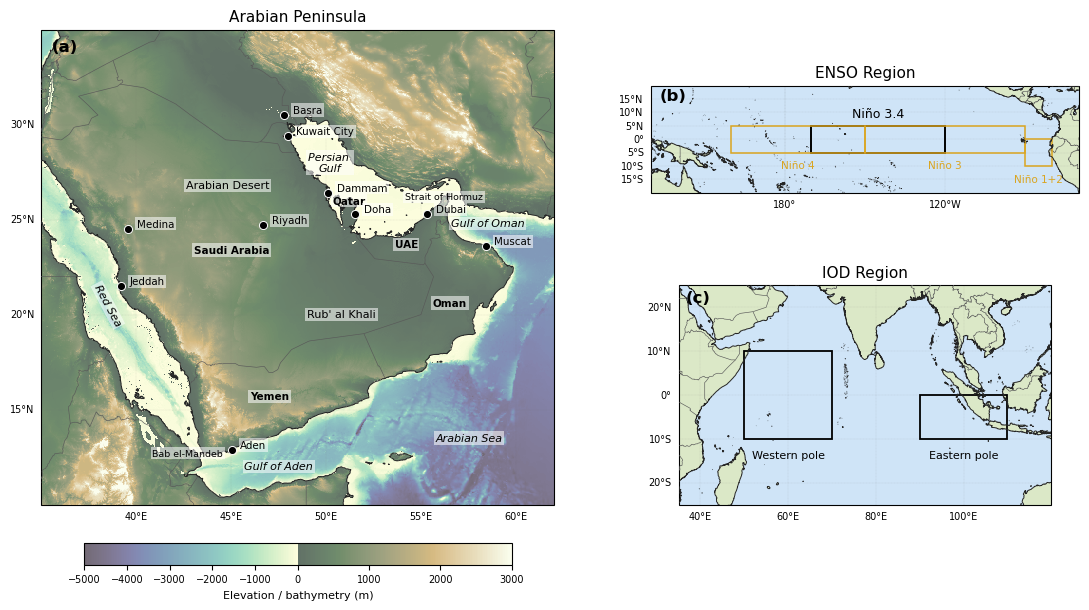

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
from matplotlib.colors import LightSource
from matplotlib.colors import TwoSlopeNorm
import cmocean

# 0–360-friendly plotting CRS
geo = ccrs.PlateCarree()
pacific_proj = ccrs.PlateCarree(central_longitude=180)

# ---------- Natural Earth layers ----------
land = cfeature.NaturalEarthFeature(
    "physical",
    "land",
    "50m",
    facecolor="#dbe8c7",   # soft green
    edgecolor="none"
)

ocean = cfeature.NaturalEarthFeature(
    "physical",
    "ocean",
    "50m",
    facecolor="#cfe4f7",   # soft blue
    edgecolor="none"
)
borders = cfeature.NaturalEarthFeature(
    "cultural", "admin_0_boundary_lines_land", "10m",
    facecolor="none", edgecolor="0.35"
)
coastline = cfeature.NaturalEarthFeature(
    "physical", "coastline", "10m",
    facecolor="none", edgecolor="0.15"
)

def add_base(ax, extent, title, extent_crs=geo, use_etopo=True):
    ax.set_extent(extent, crs=extent_crs)

    if use_etopo:
        mesh = add_etopo(ax, extent)
    else:
        mesh = None
        ax.add_feature(ocean, zorder=0)
        ax.add_feature(land, zorder=1)

    ax.add_feature(borders, linewidth=0.45, zorder=5)
    ax.add_feature(coastline, linewidth=0.7, zorder=6)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.2,
        color="0.45",
        alpha=0.35,
        linestyle="--",
        zorder=7
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

    ax.set_title(title, fontsize=11)

    return mesh

# ---------- Figure layout ----------
fig = plt.figure(figsize=(11, 6), constrained_layout=True)

gs = GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[1.45, 1.0],
    height_ratios=[1, 1]
)

ax_ap = fig.add_subplot(gs[:, 0], projection=geo)
ax_enso = fig.add_subplot(gs[0, 1], projection=pacific_proj)
ax_iod = fig.add_subplot(gs[1, 1], projection=geo)

# ---------- Map extents in 0–360 ----------
ap_extent = [35, 62, 10, 35]
enso_extent = [130, 290, -20, 20]
iod_extent = [35, 120, -25, 25]

# ---------- ETOPO 2022 terrain/bathymetry ----------
etopo_path = "ETOPO_2022_v1_60s_N90W180_bed.nc"
ds = xr.open_dataset(etopo_path)

# Usually named z, but this makes it safer
zname = "z" if "z" in ds.data_vars else list(ds.data_vars)[0]

# Convert ETOPO lon from -180/180 to 0/360
ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby("lon")

if ds.lat[0] > ds.lat[-1]:
    ds = ds.sortby("lat")
    
# Crop once to the useful figure domain
etopo = ds[zname].sel(
    lon=slice(35, 62),
    lat=slice(10, 35)
)

def add_etopo(ax, extent, alpha=0.65):
    sub = etopo.sel(
        lon=slice(extent[0], extent[1]),
        lat=slice(extent[2], extent[3])
    )

    lon = sub.lon.values
    lat = sub.lat.values
    elev = sub.values

    # More aggressive downsampling
    step = max(1, int(max(elev.shape) / 450))
    lon = lon[::step]
    lat = lat[::step]
    elev = elev[::step, ::step]

    

    norm = TwoSlopeNorm(
        vmin=-5000,
        vcenter=0,
        vmax=3000
    )
    
    mesh = ax.pcolormesh(
        lon, lat, elev,
        cmap=cmocean.cm.topo,
        norm=norm,
        shading="auto",
        alpha=alpha,
        transform=geo,
        zorder=0,
        rasterized = True
    )

    return mesh


mesh_ap = add_base(ax_ap, ap_extent, "Arabian Peninsula", extent_crs=geo, use_etopo=True)
add_base(ax_enso, enso_extent, "ENSO Region", extent_crs=geo, use_etopo = False)
add_base(ax_iod, iod_extent, "IOD Region", extent_crs=geo, use_etopo = False)



# ---------- Region boxes ----------
# Niño 3.4: 170W–120W = 190E–240E, 5S–5N
nino34 = Rectangle(
    (190, -5), 50, 10,
    linewidth=1.4,
    edgecolor="black",
    facecolor="none",
    transform=geo,
    zorder=5
)
ax_enso.add_patch(nino34)
ax_enso.text(
    215, 7, "Niño 3.4",
    ha="center", va="bottom",
    fontsize=9,
    transform=geo,
    zorder=6
)

# ---------- Additional ENSO regions ----------
enso_regions = {
    "Niño 1+2": {
        "xy": (270, -10),   # 90W–80W, 10S–0
        "width": 10,
        "height": 10,
        "label_xy": (275, -13)
    },
    "Niño 3": {
        "xy": (210, -5),    # 150W–90W, 5S–5N
        "width": 60,
        "height": 10,
        "label_xy": (240, -8)
    },
    "Niño 4": {
        "xy": (160, -5),    # 160E–150W, 5S–5N
        "width": 50,
        "height": 10,
        "label_xy": (185, -8)
    },
}

for name, spec in enso_regions.items():
    box = Rectangle(
        spec["xy"],
        spec["width"],
        spec["height"],
        linewidth=1.1,
        edgecolor="goldenrod",
        facecolor="none",
        transform=geo,
        zorder=5
    )
    ax_enso.add_patch(box)

    ax_enso.text(
        spec["label_xy"][0],
        spec["label_xy"][1],
        name,
        ha="center",
        va="top",
        fontsize=7.5,
        color="goldenrod",
        transform=geo,
        zorder=6
    )

# DMI west pole: 50–70E, 10S–10N
dmi_west = Rectangle(
    (50, -10), 20, 20,
    linewidth=1.3,
    edgecolor="black",
    facecolor="none",
    transform=geo,
    zorder=5
)
ax_iod.add_patch(dmi_west)
ax_iod.text(
    60, -12.5, "Western pole",
    ha="center", va="top",
    fontsize=8,
    transform=geo,
    zorder=6
)


# DMI east pole: 90–110E, 10S–0
dmi_east = Rectangle(
    (90, -10), 20, 10,
    linewidth=1.3,
    edgecolor="black",
    facecolor="none",
    transform=geo,
    zorder=5
)
ax_iod.add_patch(dmi_east)
ax_iod.text(
    100, -12.5, "Eastern pole",
    ha="center", va="top",
    fontsize=8,
    transform=geo,
    zorder=6
)


# ---------- Label helper ----------
def label(ax, text, lon, lat, size=7.5, weight="normal",
          ha="center", va="center", style="normal", rotation=0):
    ax.text(
        lon, lat, text,
        fontsize=size,
        fontweight=weight,
        fontstyle=style,
        ha=ha,
        va=va,
        rotation=rotation,
        transform=geo,
        zorder=10,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.55,
            pad=1.2
        )
    )

# ---------- AP countries ----------
country_labels = {
    "Saudi Arabia": (45.0, 23.4),
    "Yemen": (47.0, 15.7),
    "Oman": (56.5, 20.6),
    "UAE": (54.2, 23.7),
    "Qatar": (51.2, 26.0),
}

for name, (lon, lat) in country_labels.items():
    label(ax_ap, name, lon, lat, size=7.5, weight="bold")

# ---------- AP cities ----------
cities = {
    "Riyadh": (46.6753, 24.7136),
    "Jeddah": (39.1925, 21.4858),
    "Aden": (45.0187, 12.8855),
    "Muscat": (58.3829, 23.5880),
    "Doha": (51.5200, 25.2760),
    "Dubai": (55.2962, 25.2770),
    "Dammam": (50.0888, 26.4207),
    "Medina": (39.5692, 24.5247),
    "Kuwait City": (47.9774, 29.3759),
    "Basra": (47.7835, 30.5085),
}


for city, (lon, lat) in cities.items():
    ax_ap.scatter(
        lon, lat,
        s=34,
        color="black",
        edgecolor="white",
        linewidth=0.7,
        transform=geo,
        zorder=20
    )
    label(ax_ap, city, lon + 0.45, lat + 0.25, size=7.4, ha="left")

# ---------- Seas / gulfs ----------
label(ax_ap, "Red Sea", 38.5, 20.5, size=8, style="italic", rotation=-62)
label(ax_ap, "Gulf of Aden", 47.5, 12.0, size=8, style="italic")
label(ax_ap, "Gulf of Oman", 58.5, 24.8, size=8, style="italic")
label(ax_ap, "Persian \nGulf", 50.2, 28.0, size=8, style="italic")
label(ax_ap, "Arabian Sea", 57.5, 13.5, size=8, style="italic")

# ---------- Geographic features ----------
label(ax_ap, "Bab el-Mandeb", 42.7, 12.7, size=6.8)
label(ax_ap, "Strait of Hormuz", 56.2, 26.2, size=6.8)
label(ax_ap, "Arabian Desert", 44.8, 26.8, size=8)
label(ax_ap, "Rub' al Khali", 50.8, 20.0, size=8)

ax_ap.text(
    0.02, 0.98, "(a)",
    transform=ax_ap.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
    zorder=100
)

ax_enso.text(
    0.02, 0.98, "(b)",
    transform=ax_enso.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
    zorder=100
)

ax_iod.text(
    0.02, 0.98, "(c)",
    transform=ax_iod.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
    zorder=100
)

cbar = fig.colorbar(
    mesh_ap,
    ax=ax_ap,
    orientation="horizontal",
    fraction=0.045,
    pad=0.045
)
cbar.set_label("Elevation / bathymetry (m)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("reference_map_AP_ENSO_IOD.pdf", dpi=300, bbox_inches="tight")
plt.show()